In [1]:
import pandas as pd 
import torch
import matplotlib.pyplot as plt
import tifffile as tiff
import numpy as np
# import napari
import os

import shutil
from glob import glob

In [2]:
import sys
sys.path.append('../src')

%load_ext autoreload
%autoreload 2

In [3]:
# img_name = '20260717T120225_pA_Activin_D4_48hr_W0027'
# channel_names = ['Sox17', 'Activin', 'FoxA2', 'Hoechst']
img_name = 'W8_pattern1_Sox17_Brachyury'
# img_name = 'W8_pattern2_Sox17_Brachyury'
# img_name = 'W14_pattern2_Sox17_Brachyury_no geltrex'
channel_names = ['Sox17', 'BMP4', 'T', 'Hoechst']
# img_name = 'W10_Cultrex_mask7'
# channel_names = ['T', 'BMP4', 'ISL1','Hoechst']

cell_df = pd.read_parquet(f'../data/stitched/{img_name}_features.parquet')
print(cell_df.shape)
cell_df.head(3)

(111511, 22)


,centroid_y,centroid_x,area,perimeter,perimeter_crofton,eccentricity,solidity,extent,major_axis_length,minor_axis_length,...,circularity,aspect_ratio,Sox17_mean,BMP4_mean,T_mean,Hoechst_mean,Sox17+,BMP4+,T+,Hoechst+
cell_id,,,,,,,,,,,,,,,,,,,,,
1,9.058548,629.522248,427.0,85.941125,84.158813,0.603269,0.908511,0.640180,27.763694,22.142602,...,0.757598,1.253859,264.735363,124.067916,347.723653,1366.845433,False,False,False,True
2,9.803440,4872.491400,407.0,76.526912,75.233579,0.618904,0.946512,0.740000,26.030466,20.446056,...,0.903610,1.273129,216.383292,118.837838,198.417690,758.594595,False,False,False,True
3,9.231250,7124.062500,160.0,54.970563,54.796878,0.911222,0.879121,0.661157,22.911059,9.437440,...,0.669604,2.427677,226.725000,136.756250,379.668750,1362.175000,False,False,False,True


In [4]:
if_cols = [c+'_mean' for c in channel_names if c != 'Hoechst']

# cell_df['Activin_mean'] = cell_df['Activin+'].astype(float)
cell_df['BMP4_mean'] = cell_df['BMP4+'].astype(float)

In [5]:
yif='Sox17'
predict_type = f'mask_xBMP4_y{yif}_cropped'
# predict_type = f'mask_xActivin_y{yif}'
fig_dir = f'../results/figures/{img_name}/{predict_type}'
os.makedirs(fig_dir, exist_ok=True)

In [6]:
label_mask = np.load(f'../data/stitched/{img_name}.npy')
cell_mask = np.where(label_mask > 1, True, False)
print(label_mask.shape, cell_mask.shape)

(5996, 7937) (5996, 7937)


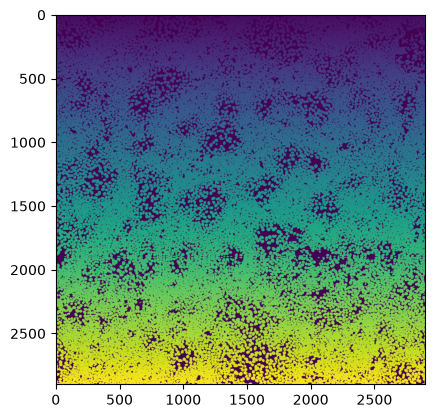

In [7]:
crop = [(100, 3000),(100, 3000)]
label_mask_ = label_mask[crop[0][0]:crop[0][1], crop[1][0]:crop[1][1]]
plt.imshow(label_mask_)

In [8]:
label_mask = label_mask_
cell_df = cell_df[cell_df.index.isin(np.unique(label_mask))]
cell_df.shape

# label_mask.shape
# crop = [(0, label_mask.shape[0]), (0, label_mask.shape[1])]

(20387, 22)

In [9]:
# GLOBAL_X_COLS = ['Activin_mean']
# NEIGHBOR_X_COLS = ['Activin_mean']
GLOBAL_X_COLS = ['BMP4_mean']
NEIGHBOR_X_COLS = ['BMP4_mean']

SEED = 0
SCALING = 'log1p_standard'  # 'log1p_standard' | 'arcsinh' | 'robust' -- see models.gnn.ColumnScaler;
Y_COLS = [f'{yif}_mean']

### Prediction

In [22]:
from tools.morphology import split_indices, indices_to_mask, r2_table, plot_pred_vs_actual, plot_loss_curves, local_density
from tools.qc import get_bimodal_threshold
from models.gnn import build_prediction_data, train_neighbor_predictor, NeighborIFPredictor, predict_df as gnn_predict_df, border_mask, save_model
from models.gat import NeighborIFPredictorGAT

PRED_RADIUS = 100  # px -- create a graph (every pair within radius is connected), NOT k-NN
DENSITY_RADIUS = 50 # compute number of cells within this radius as feature
NUM_LAYERS = 4
NORMALIZE_DATA = False
HIDDEN_DIM = 128
LR = 1e-4
NUM_HEADS = 2
DISTANCE_INIT = True

USE_AMP = True          # Autocast 
USE_CHECKPOINT = False  # Recompute forward instead of storing
TRAIN_DEVICE = 'mps'

N = len(cell_df)
centroids = cell_df[['centroid_y', 'centroid_x']].to_numpy(dtype=np.float32)
cell_df['local_density'] = local_density(centroids, radius=DENSITY_RADIUS)  # same neighborhood as the graph itself

BORDER_RADIUS = NUM_LAYERS * PRED_RADIUS

crop_y0, crop_x0 = crop[0][0], crop[1][0]
local_centroids = centroids - np.array([crop_y0, crop_x0], dtype=np.float32)
is_border = border_mask(local_centroids, label_mask.shape, BORDER_RADIUS)
valid_target_idx = np.where(~is_border)[0]
print(f'{is_border.sum()} / {N} cells within {BORDER_RADIUS}px ({NUM_LAYERS} layers x {PRED_RADIUS}px) of the CROPPED border -- excluded as targets')

train_pos, val_pos, test_pos = split_indices(len(valid_target_idx), val_frac=0.15, test_frac=0.15, seed=SEED)
train_idx, val_idx, test_idx = valid_target_idx[train_pos], valid_target_idx[val_pos], valid_target_idx[test_pos]
train_mask = indices_to_mask(train_idx, N)
val_mask = indices_to_mask(val_idx, N)
test_mask = indices_to_mask(test_idx, N)

pred_data = build_prediction_data(
    cell_df, if_cols, radius=PRED_RADIUS, global_x_cols=GLOBAL_X_COLS, train_idx=train_idx, scaling=SCALING,
    neighbor_x_cols=NEIGHBOR_X_COLS, 
    y_cols=Y_COLS,
    no_background_cols=['local_density', 'Activin_mean', 'BMP4_mean'],
    no_transform_cols=['local_density', 'Activin_mean', 'BMP4_mean'],
    no_scale_cols=['Activin_mean', 'BMP4_mean'],
    # custom_background={'Sox17_mean': 0},
    normalize_data=NORMALIZE_DATA,
)
print('neighbor_x_cols (seen only via neighbors):', pred_data['neighbor_x_cols'])
print('global_x_cols (seen directly, incl. self):', pred_data['global_x_cols'])
print('y_cols (predicted):', pred_data['y_cols'])
print(f"{N} cells, {pred_data['edge_index'].shape[1]} directed edges (radius={PRED_RADIUS}px)")

9797 / 20387 cells within 400px (4 layers x 100px) of the CROPPED border -- excluded as targets
neighbor_x_cols (seen only via neighbors): ['BMP4_mean']
global_x_cols (seen directly, incl. self): ['BMP4_mean']
y_cols (predicted): ['Sox17_mean']
20387 cells, 1585234 directed edges (radius=100px)


In [11]:
# check if the dynamic range is good enough for prediction
data = pd.DataFrame(pred_data['y'], columns=pred_data['y_cols'])
for i, x in enumerate(pred_data['global_x_cols']):
    data[x] = pred_data['x_global'][:, i]
for i, x in enumerate(pred_data['neighbor_x_cols']):
    data[x] = pred_data['x_neighbor'][:, i]

data['centroid_x'] = cell_df['centroid_x'].values
data['centroid_y'] = cell_df['centroid_y'].values
print(data.shape)
data.tail(2)

(20387, 4)


,Sox17_mean,BMP4_mean,centroid_x,centroid_y
20385,-0.117485,0.0,2561.664234,3004.313869
20386,-0.117485,0.0,2782.709480,3010.529052


,Sox17_mean,BMP4_mean,centroid_x,centroid_y
count,20387.000000,20387.000000,20387.000000,20387.000000
mean,0.002278,0.040516,1556.655067,1560.256442
std,1.095683,0.197171,848.874027,836.053026
min,-0.117485,0.000000,83.948905,86.551313
25%,-0.117485,0.000000,814.619596,855.503372
50%,-0.117485,0.000000,1541.442822,1544.969298
75%,-0.117485,0.000000,2315.721551,2290.757745
max,56.850327,1.000000,3014.377460,3011.891525


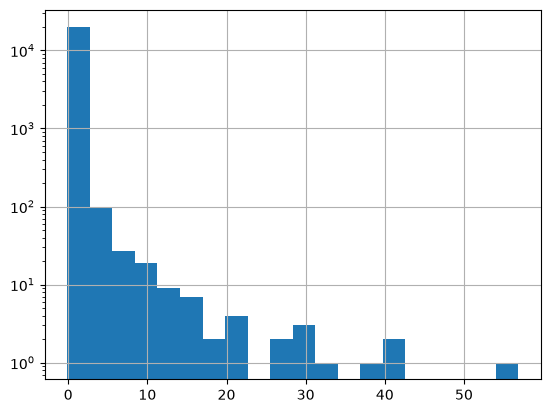

In [14]:
display(data.describe())
data['Sox17_mean'].hist(bins=20)
_ = plt.semilogy()

In [15]:
# data.to_csv(f'../data/training/{img_name}_scaled.csv')

import gc
import torch

gc.collect()
torch.mps.empty_cache()

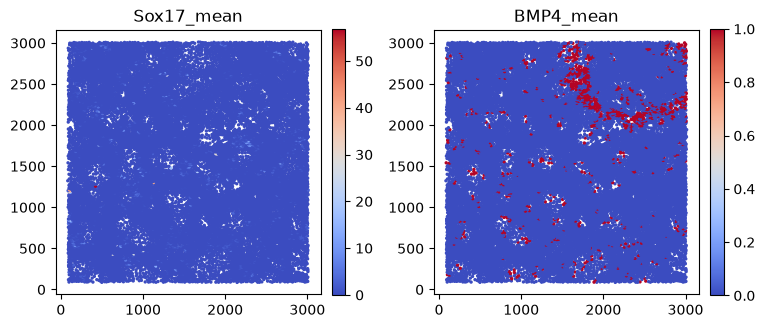

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = [x for x in data.columns if 'centroid' not in x]
fig, axs = plt.subplots(1, 4, figsize=(15, 5))
axs = axs.flatten()

for i, col in enumerate(cols):
    ax = axs[i]
    sc = ax.scatter(
        data['centroid_x'], data['centroid_y'],
        c=data[col], cmap='coolwarm',
        s=2
    )
    ax.set_title(col, fontsize=12)
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

# Hide unused subplots
for j in range(len(cols), len(axs)):
    axs[j].set_visible(False)

fig.tight_layout()
plt.savefig(f'{fig_dir}/features.png', dpi=300)
plt.show()

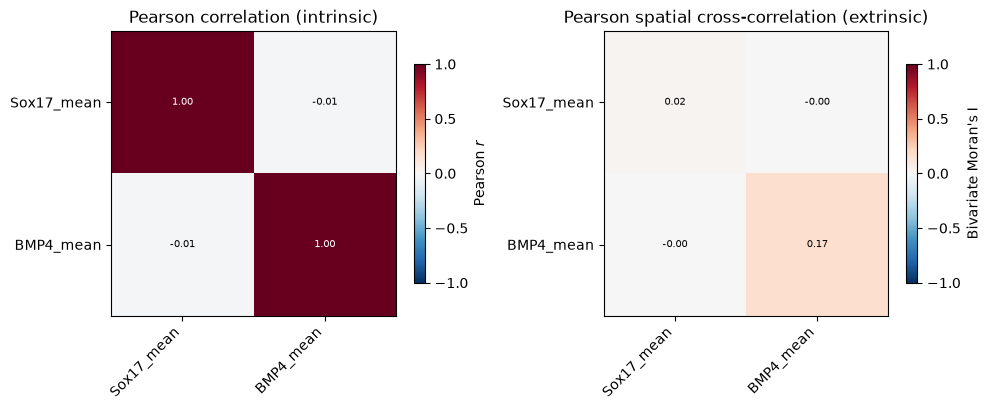

In [18]:
from tools.morphology import plot_correlation_heatmap, plot_spatial_cross_correlation

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
plot_correlation_heatmap(data, cols, title=f'Pearson correlation (intrinsic)', corr_type='pearson', ax=axs[0])
plot_spatial_cross_correlation(data, cols, title='Pearson spatial cross-correlation (extrinsic)', corr_type='pearson', edge_index=pred_data['edge_index'], ax=axs[1])
plt.tight_layout()

/Users/allywang/Desktop/work/F2026/OptoBMP/notebooks/../src/models/gnn.py:814: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)


GNN:   0%|          | 0/500 [00:00<?, ?it/s]

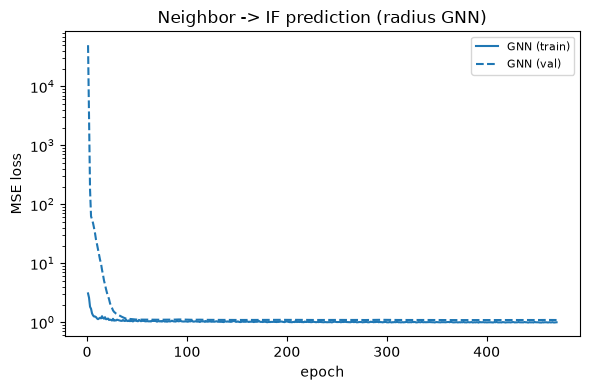

,R2,MAE
feature,,
Sox17_mean,0.013246,0.183362


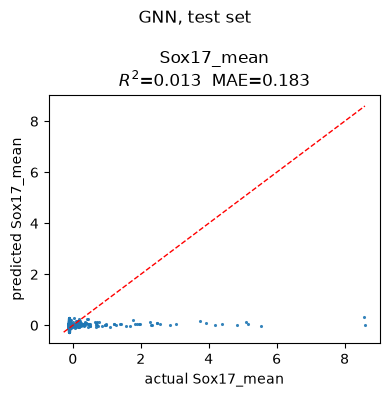

In [19]:
GNN_KWARGS = dict(
    neighbor_in_channels=len(pred_data['neighbor_x_cols']),
    global_in_channels=len(pred_data['global_x_cols']),
    num_outputs=len(pred_data['y_cols']),
    num_layers=NUM_LAYERS, 
    hidden_channels=HIDDEN_DIM,
    normalize_data=NORMALIZE_DATA,
    use_checkpoint=USE_CHECKPOINT,
)

torch.manual_seed(SEED)
gnn_model = NeighborIFPredictor(**GNN_KWARGS)
gnn_history = train_neighbor_predictor(
    gnn_model, pred_data, train_mask, val_mask, desc='GNN', 
    epochs=500, patience=100, lr=LR, use_amp=USE_AMP, device=TRAIN_DEVICE,
)
fig_gnn_loss = plot_loss_curves({'GNN': gnn_history}, title='Neighbor -> IF prediction (radius GNN)')
plt.show()

gnn_pred_test, gnn_true_test = gnn_predict_df(gnn_model, pred_data, test_mask, cell_df.index,  y_scaler=None)
gnn_r2 = r2_table(gnn_true_test, gnn_pred_test)
display(gnn_r2)
fig_gnn_pred = plot_pred_vs_actual(gnn_true_test, gnn_pred_test, title='GNN, test set')
plt.show()

fig_gnn_loss.savefig(f'{fig_dir}/gnn_loss_curve.png', dpi=300, bbox_inches='tight')
fig_gnn_pred.savefig(f'{fig_dir}/gnn_r2.png', dpi=300, bbox_inches='tight')

save_model(
    f'../results/models/{img_name}_{predict_type}_gnn.pt', gnn_model, GNN_KWARGS, pred_data, radius=PRED_RADIUS,
    density_radius=DENSITY_RADIUS, normalize_data=NORMALIZE_DATA,
)

In [21]:
gc.collect()
torch.mps.empty_cache()

In [ ]:
GAT_KWARGS = dict(
    neighbor_in_channels=len(pred_data['neighbor_x_cols']),
    global_in_channels=len(pred_data['global_x_cols']),
    num_outputs=len(pred_data['y_cols']),
    num_layers=NUM_LAYERS,
    hidden_channels=HIDDEN_DIM,
    heads=NUM_HEADS,
    distance_init=DISTANCE_INIT,
    use_checkpoint=USE_CHECKPOINT,
)

torch.manual_seed(SEED)
gat_model = NeighborIFPredictorGAT(**GAT_KWARGS)
gat_history = train_neighbor_predictor(
    gat_model, pred_data, train_mask, val_mask, desc='GAT',
    epochs=500, lr=LR, patience=100, device=TRAIN_DEVICE, use_amp=USE_AMP,
    # batch_size=32, num_neighbors=[-1, 5, 5, 5]
)
fig_gat_loss = plot_loss_curves({'GAT': gat_history}, title='Neighbor -> IF prediction (radius GAT)')
plt.show()

gat_pred_test, gat_true_test = gnn_predict_df(gat_model, pred_data, test_mask, cell_df.index,  y_scaler=None)
gat_r2 = r2_table(gat_true_test, gat_pred_test)
display(gat_r2)
fig_gat_pred = plot_pred_vs_actual(gat_true_test, gat_pred_test, title='GAT, test set')
plt.show()

fig_gat_loss.savefig(f'{fig_dir}/gat_loss_curve.png', dpi=300, bbox_inches='tight')
fig_gat_pred.savefig(f'{fig_dir}/gat_r2.png', dpi=300, bbox_inches='tight')

save_model(
    f'../results/models/{img_name}_{predict_type}_gat.pt', gat_model, GAT_KWARGS, pred_data, radius=PRED_RADIUS,
    density_radius=DENSITY_RADIUS, normalize_data=NORMALIZE_DATA
)


/Users/allywang/Desktop/work/F2026/OptoBMP/notebooks/../src/models/gnn.py:814: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)


GAT:   0%|          | 0/500 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
comparison = pd.concat({'GNN (fixed weights)': gnn_r2, 'GAT (learned attention)': gat_r2}, axis=1)
display(comparison)

GNN (fixed weights)           GAT (learned attention)         
                            R2       MAE                      R2      MAE
feature                                                                  
Sox17_mean            0.217608  0.514227                0.145577  0.57904

### Gradient-based neighbor sensitivity

/var/folders/1g/26g72_qd5qn5k3q89zh7_6240000gn/T/ipykernel_48563/3175306601.py:9: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  centroids_t = torch.from_numpy(centroids)


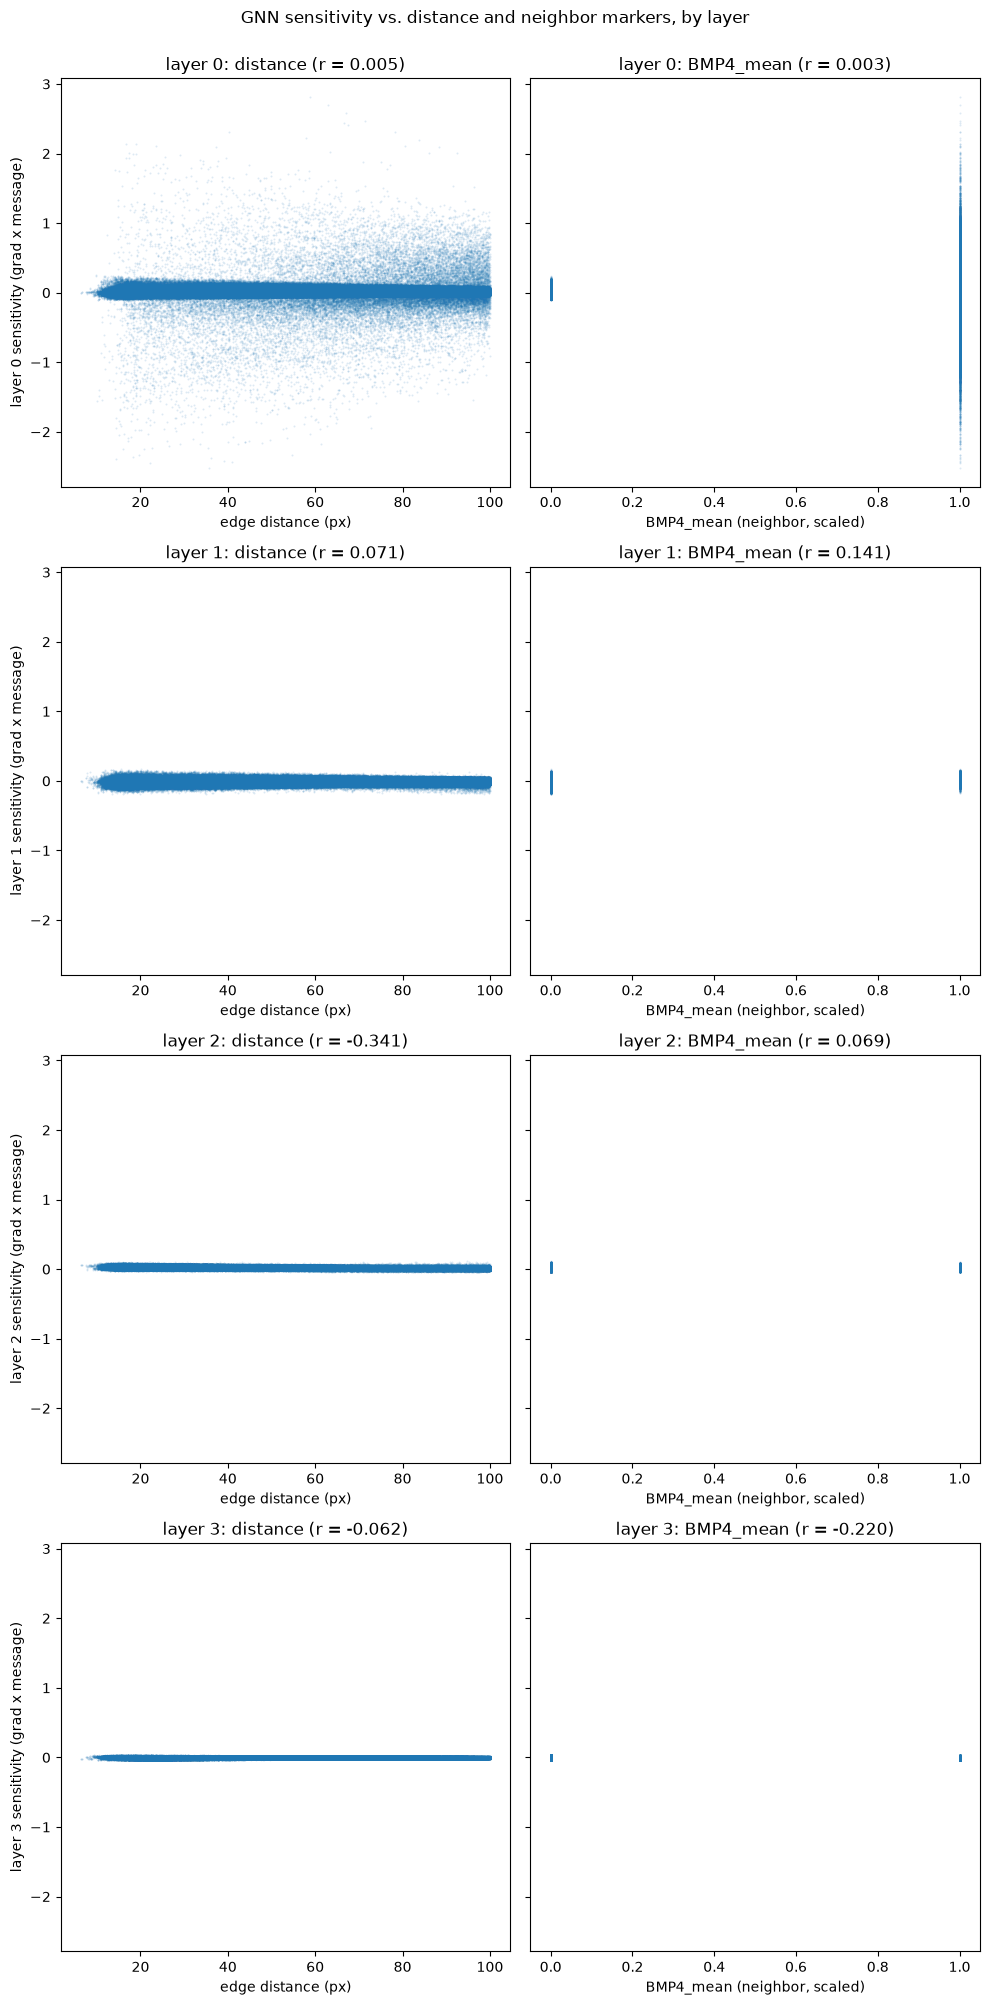

In [ ]:
# One list entry per GNN layer (models.gnn.NeighborIFPredictor.message_sensitivity_by_layer)
# -- same (E,) shape as GAT's layer_attentions below, but each entry is a computed
# grad-times-message contribution rather than a learned attention weight, since
# WeightedNeighborConv has nothing learned to read off an edge directly.
layer_sensitivities = gnn_model.message_sensitivity_by_layer(
    pred_data['x_neighbor'], pred_data['edge_index'], pred_data['edge_weight'], pred_data['x_global']
)

centroids_t = torch.from_numpy(centroids)
src, dst = pred_data['edge_index']
edge_dist = torch.norm(centroids_t[src] - centroids_t[dst], dim=1)

# One ROW per layer -- only the FIRST layer's sensitivity is a direct function of
# these raw neighbor_x_cols values; deeper layers' sensitivity is built from the
# embeddings earlier layers produced, same caveat as the GAT section below.
neighbor_cols = pred_data['neighbor_x_cols']
n_panels = 1 + len(neighbor_cols)
n_layers = len(layer_sensitivities)
fig, axes = plt.subplots(n_layers, n_panels, figsize=(5 * n_panels, 5 * n_layers), sharey=True, squeeze=False)

for layer_idx, layer_sens in enumerate(layer_sensitivities):
    ax = axes[layer_idx, 0]
    ax.scatter(edge_dist.numpy(), layer_sens.numpy(), s=2, alpha=0.15, linewidths=0)
    corr = np.corrcoef(edge_dist.numpy(), layer_sens.numpy())[0, 1]
    ax.set_xlabel('edge distance (px)')
    ax.set_ylabel(f'layer {layer_idx} sensitivity (grad x message)')
    ax.set_title(f'layer {layer_idx}: distance (r = {corr:.3f})')

    for j, col in enumerate(neighbor_cols):
        ax = axes[layer_idx, j + 1]
        values = pred_data['x_neighbor'][src, j].numpy()
        ax.scatter(values, layer_sens.numpy(), s=2, alpha=0.15, linewidths=0)
        corr = np.corrcoef(values, layer_sens.numpy())[0, 1]
        ax.set_xlabel(f'{col} (neighbor, scaled)')
        ax.set_title(f'layer {layer_idx}: {col} (r = {corr:.3f})')

fig.suptitle('GNN sensitivity vs. distance and neighbor markers, by layer', y=1)
fig.tight_layout()
fig.savefig(f'{fig_dir}/gnn_sensitivity_corrs.png', dpi=300, bbox_inches='tight')
plt.show()

# Cells below (single-example-cell map, global-cols correlation) use the FINAL
# layer's sensitivity -- the one closest to the prediction head.
sens_weights = layer_sensitivities[-1]

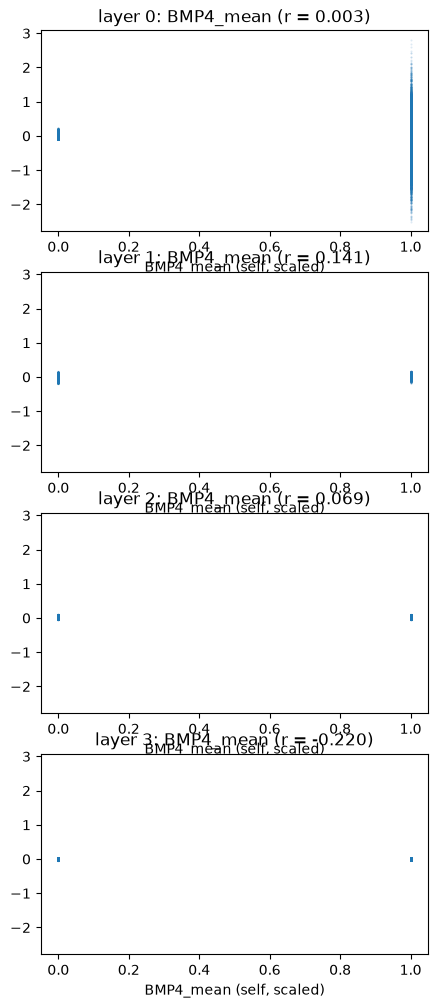

In [ ]:
global_cols = pred_data['global_x_cols']
n_panels = len(global_cols)
n_layers = len(layer_sensitivities)

fig, axes = plt.subplots(n_layers, n_panels, figsize=(5 * n_panels, 3 * n_layers), sharey=True, squeeze=False)

for layer_idx, layer_sens in enumerate(layer_sensitivities):
    for j, col in enumerate(global_cols):
        ax = axes[layer_idx, j]
        values = pred_data['x_global'][src, j].numpy()
        ax.scatter(values, layer_sens.numpy(), s=2, alpha=0.15, linewidths=0)
        corr = np.corrcoef(values, layer_sens.numpy())[0, 1]
        ax.set_xlabel(f'{col} (self, scaled)')
        ax.set_title(f'layer {layer_idx}: {col} (r = {corr:.3f})')

fig.savefig(f'{fig_dir}/gnn_sensitivity_corrs_intrinsic.png', dpi=300, bbox_inches='tight')

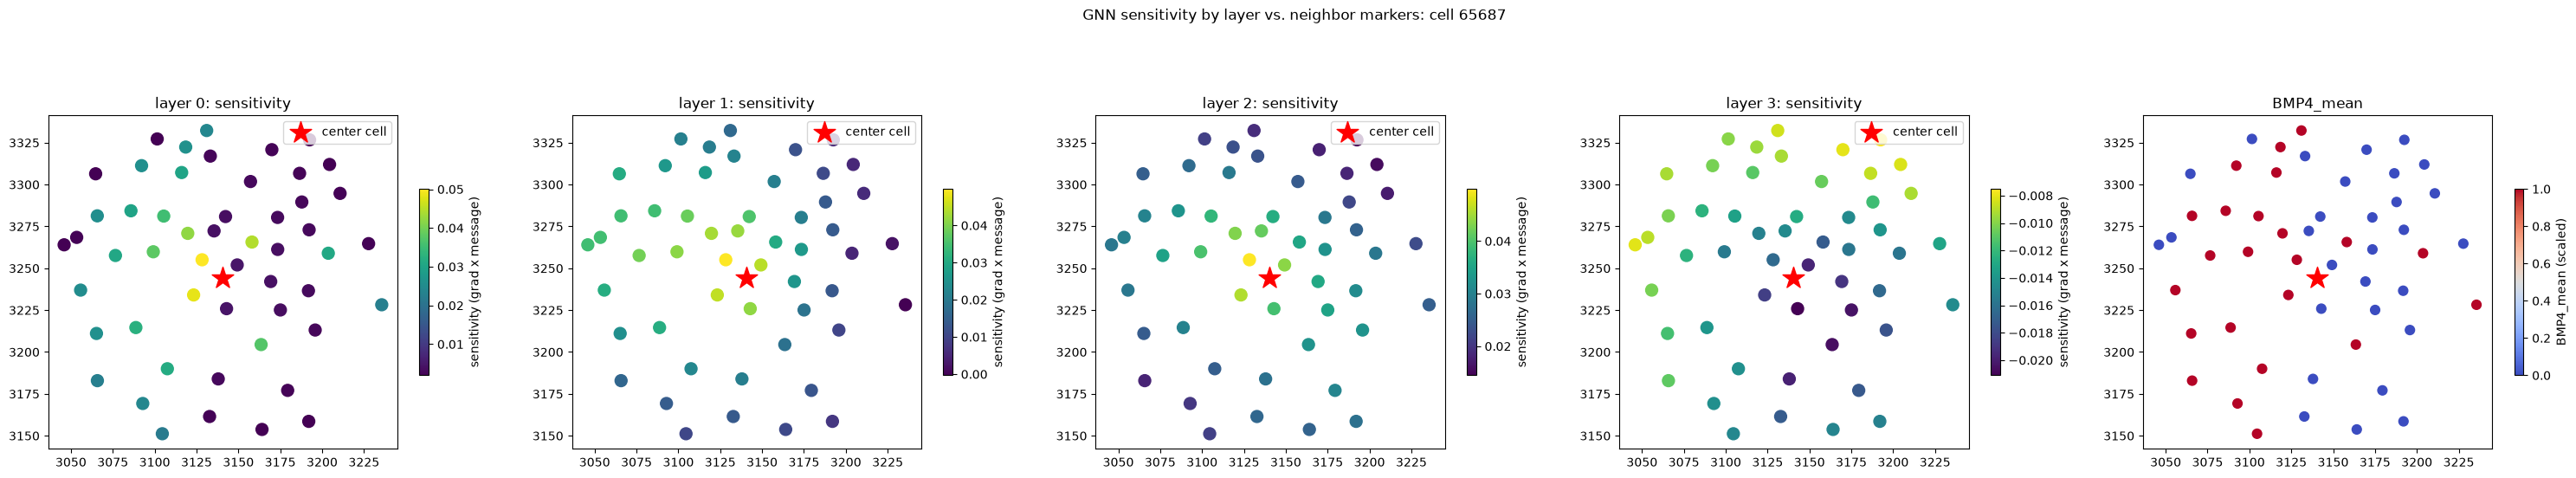

In [ ]:
# One example (held-out test) cell: one sensitivity panel PER LAYER (positions are
# identical across layers -- only the coloring/sensitivity values change, since each
# layer's messages are a genuinely different, downstream quantity from the previous
# layer's, see the "distance and neighbor markers, by layer" cell above), then one
# panel per neighbor marker (these don't depend on layer at all, so shown once
# rather than repeated).

example_cell_pos = np.random.choice(test_idx)
# example_cell_pos = test_idx[i]
mask_edges = (dst == example_cell_pos)
neighbor_pos = src[mask_edges].numpy()

n_layers = len(layer_sensitivities)
n_panels = n_layers + len(neighbor_cols)
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 6))

for layer_idx, layer_sens in enumerate(layer_sensitivities):
    neighbor_sens = layer_sens[mask_edges].numpy()
    ax = axes[layer_idx]
    sc = ax.scatter(centroids[neighbor_pos, 1], centroids[neighbor_pos, 0], c=neighbor_sens, cmap='viridis', s=100)
    ax.scatter(centroids[example_cell_pos, 1], centroids[example_cell_pos, 0], c='red', s=350, marker='*', label='center cell')
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(sc, ax=ax, label='sensitivity (grad x message)', shrink=0.4)
    ax.set_title(f'layer {layer_idx}: sensitivity')
    ax.legend()

for j, col in enumerate(neighbor_cols):
    ax = axes[n_layers + j]
    values = pred_data['x_neighbor'][neighbor_pos, j].numpy()
    sc = ax.scatter(centroids[neighbor_pos, 1], centroids[neighbor_pos, 0], c=values, cmap='coolwarm', s=60)
    ax.scatter(centroids[example_cell_pos, 1], centroids[example_cell_pos, 0], c='red', s=350, marker='*')
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(sc, ax=ax, label=f'{col} (scaled)', shrink=0.4)
    ax.set_title(col)

fig.suptitle(f'GNN sensitivity by layer vs. neighbor markers: cell {cell_df.index[example_cell_pos]}', y=1)
fig.tight_layout()
fig.savefig(f'{fig_dir}/gnn_sensitivity_example.png', dpi=300, bbox_inches='tight')
plt.show()

### Understanding the GAT: attention weights

`WeightedNeighborConv` (the fixed-weight GNN) weights every neighbor by a deterministic
function of distance alone -- there's nothing to "interpret" there beyond the decay
curve itself. `GATConv` (the GAT) instead LEARNS its neighbor weighting, so inspecting
those learned attention weights directly shows what the model actually uses, rather
than assuming distance is what matters.

`GATConv` hands back the exact per-edge attention coefficient via
`return_attention_weights=True` -- softmax-normalized so each cell's incoming
attention still sums to 1, same property as the fixed GNN's `edge_weight`, just
learned instead of fixed. Two things worth checking:
- **Attention vs. distance**: if attention just tracks the same exponential decay the
  fixed GNN assumes, geometry is doing all the work and the learned attention isn't
  adding anything beyond it. If it doesn't correlate with distance, the model has
  found something in the neighbor FEATURES themselves that geometry alone can't explain.
- **Per-cell attention map**: for one example cell, which of its neighbors does the
  model actually lean on -- the physically closest ones, or ones with a similar/
  dissimilar marker profile regardless of exact distance?

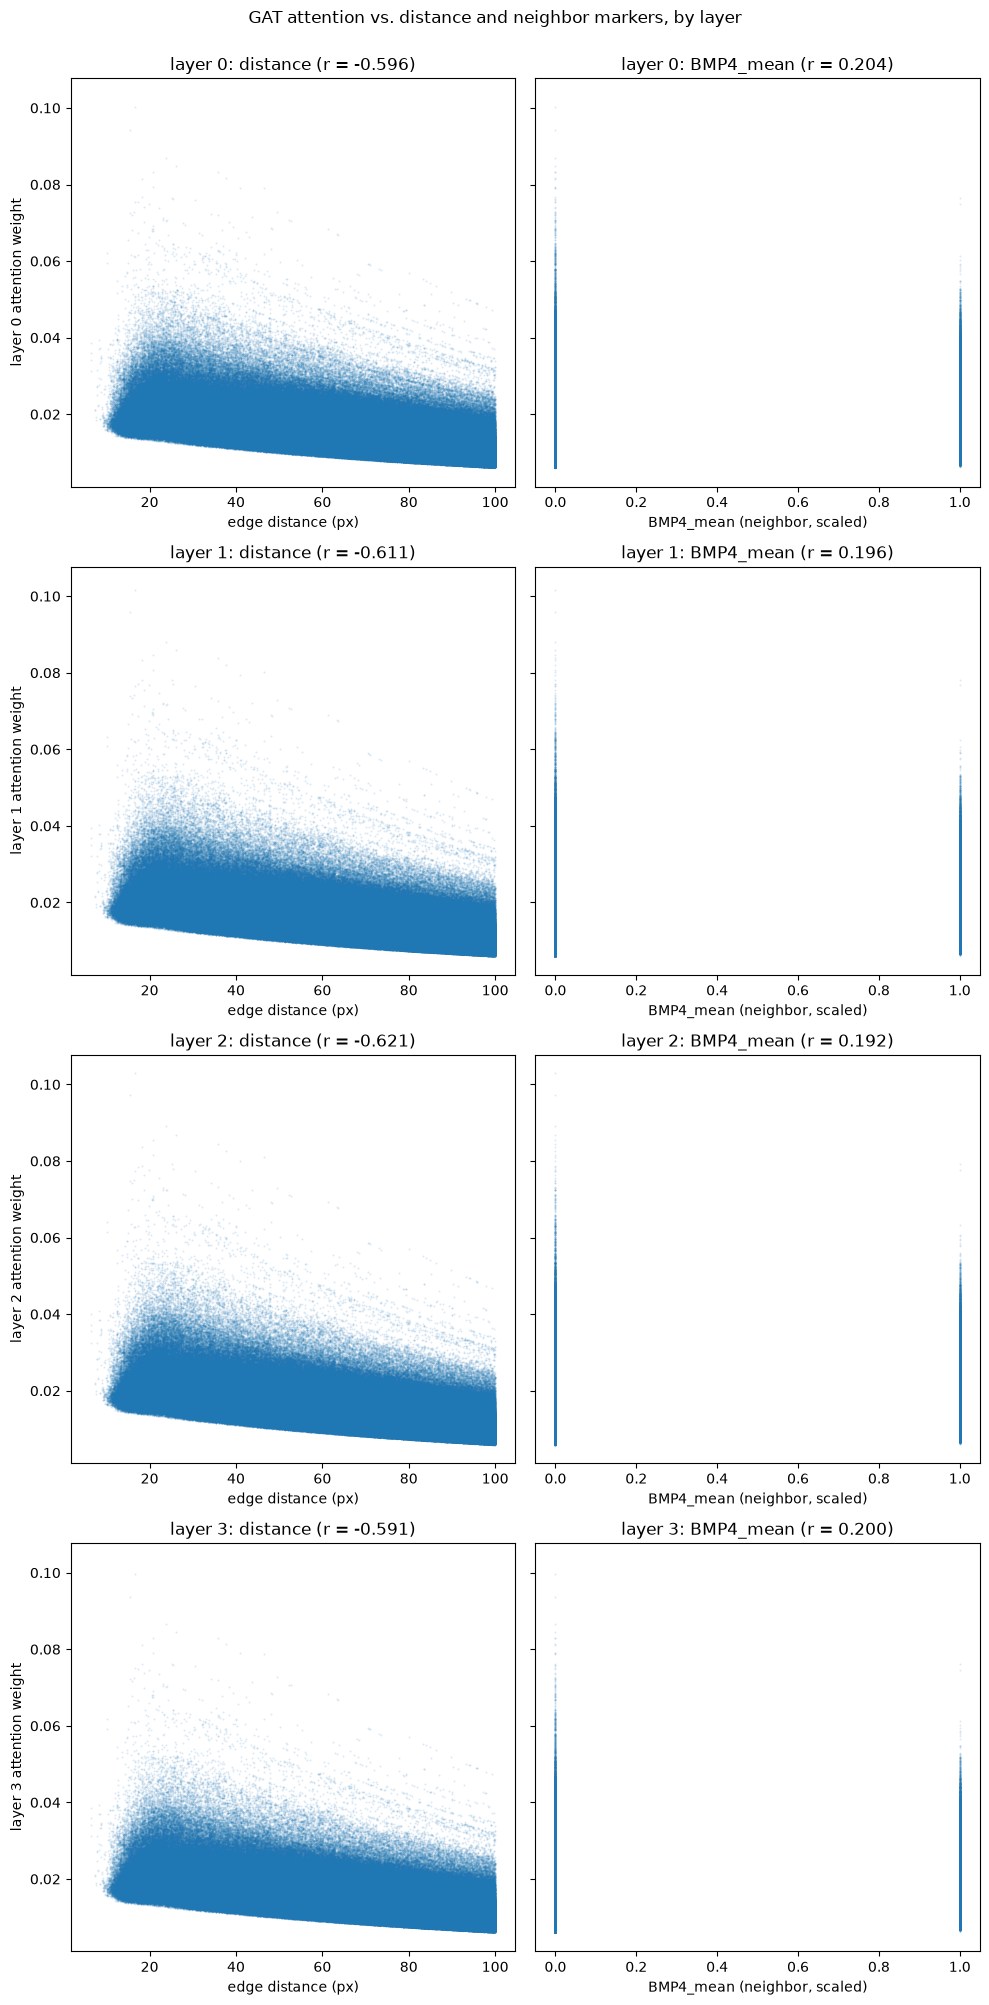

In [ ]:
edge_attr = pred_data['edge_weight'].unsqueeze(-1)
# One list entry per GAT layer (models.gat.NeighborRadiusGAT.attention_by_layer) --
# with NUM_LAYERS > 1 there's no longer a single "the" attention weight per edge:
# every non-final layer has heads > 1 (concat=True), so a single conv(...,
# return_attention_weights=True) call on ONE layer comes back (E, heads), not the
# (E,) a scalar-per-edge plot needs -- attention_by_layer head-averages each layer
# down to (E,) and replays the SAME forward computation (dropout disabled) so the
# captured attention matches what a real forward pass actually used.
layer_attentions = gat_model.encoder.attention_by_layer(pred_data['x_neighbor'], pred_data['edge_index'], edge_attr)

centroids_t = torch.from_numpy(centroids)
src, dst = pred_data['edge_index']
edge_dist = torch.norm(centroids_t[src] - centroids_t[dst], dim=1)

# One ROW per layer -- only the FIRST layer's attention operates directly on these raw
# neighbor_x_cols values; deeper layers' attention operates on the embeddings that
# resulted from earlier layers, so a correlation there reflects an indirect/aggregate
# relationship with the raw marker, not a direct one.
neighbor_cols = pred_data['neighbor_x_cols']
n_panels = 1 + len(neighbor_cols)
n_layers = len(layer_attentions)
fig, axes = plt.subplots(n_layers, n_panels, figsize=(5 * n_panels, 5 * n_layers), sharey=True, squeeze=False)

for layer_idx, layer_att in enumerate(layer_attentions):
    ax = axes[layer_idx, 0]
    ax.scatter(edge_dist.numpy(), layer_att.numpy(), s=2, alpha=0.15, linewidths=0)
    corr = np.corrcoef(edge_dist.numpy(), layer_att.numpy())[0, 1]
    ax.set_xlabel('edge distance (px)')
    ax.set_ylabel(f'layer {layer_idx} attention weight')
    ax.set_title(f'layer {layer_idx}: distance (r = {corr:.3f})')

    for j, col in enumerate(neighbor_cols):
        ax = axes[layer_idx, j + 1]
        values = pred_data['x_neighbor'][src, j].numpy()
        ax.scatter(values, layer_att.numpy(), s=2, alpha=0.15, linewidths=0)
        corr = np.corrcoef(values, layer_att.numpy())[0, 1]
        ax.set_xlabel(f'{col} (neighbor, scaled)')
        ax.set_title(f'layer {layer_idx}: {col} (r = {corr:.3f})')

fig.suptitle('GAT attention vs. distance and neighbor markers, by layer', y=1)
fig.tight_layout()
fig.savefig(f'{fig_dir}/gat_attention_corrs.png', dpi=300, bbox_inches='tight')
plt.show()

# Cells below (single-example-cell map, global-cols correlation) use the FINAL layer's
# attention -- the one that most directly determines what reaches the prediction head.
att_weights = layer_attentions[-1]

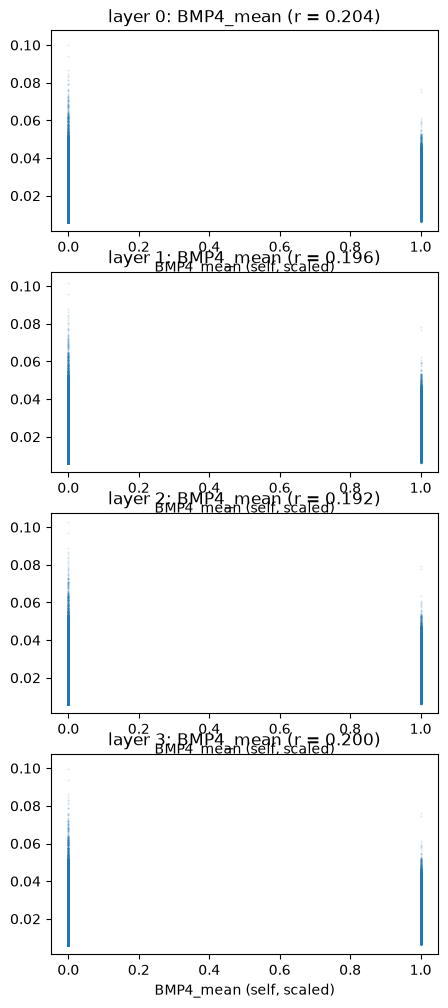

In [ ]:
global_cols = pred_data['global_x_cols']
n_panels = len(global_cols)
n_layers = len(layer_attentions)

fig, axes = plt.subplots(n_layers, n_panels, figsize=(5 * n_panels, 3 * n_layers), sharey=True, squeeze=False)

for layer_idx, layer_att in enumerate(layer_attentions):
    for j, col in enumerate(global_cols):
        ax = axes[layer_idx, j]
        values = pred_data['x_global'][src, j].numpy()
        ax.scatter(values, layer_att.numpy(), s=2, alpha=0.15, linewidths=0)
        corr = np.corrcoef(values, layer_att.numpy())[0, 1]
        ax.set_xlabel(f'{col} (self, scaled)')
        ax.set_title(f'layer {layer_idx}: {col} (r = {corr:.3f})')

fig.savefig(f'{fig_dir}/gat_attention_corrs_intrinsic.png', dpi=300, bbox_inches='tight')

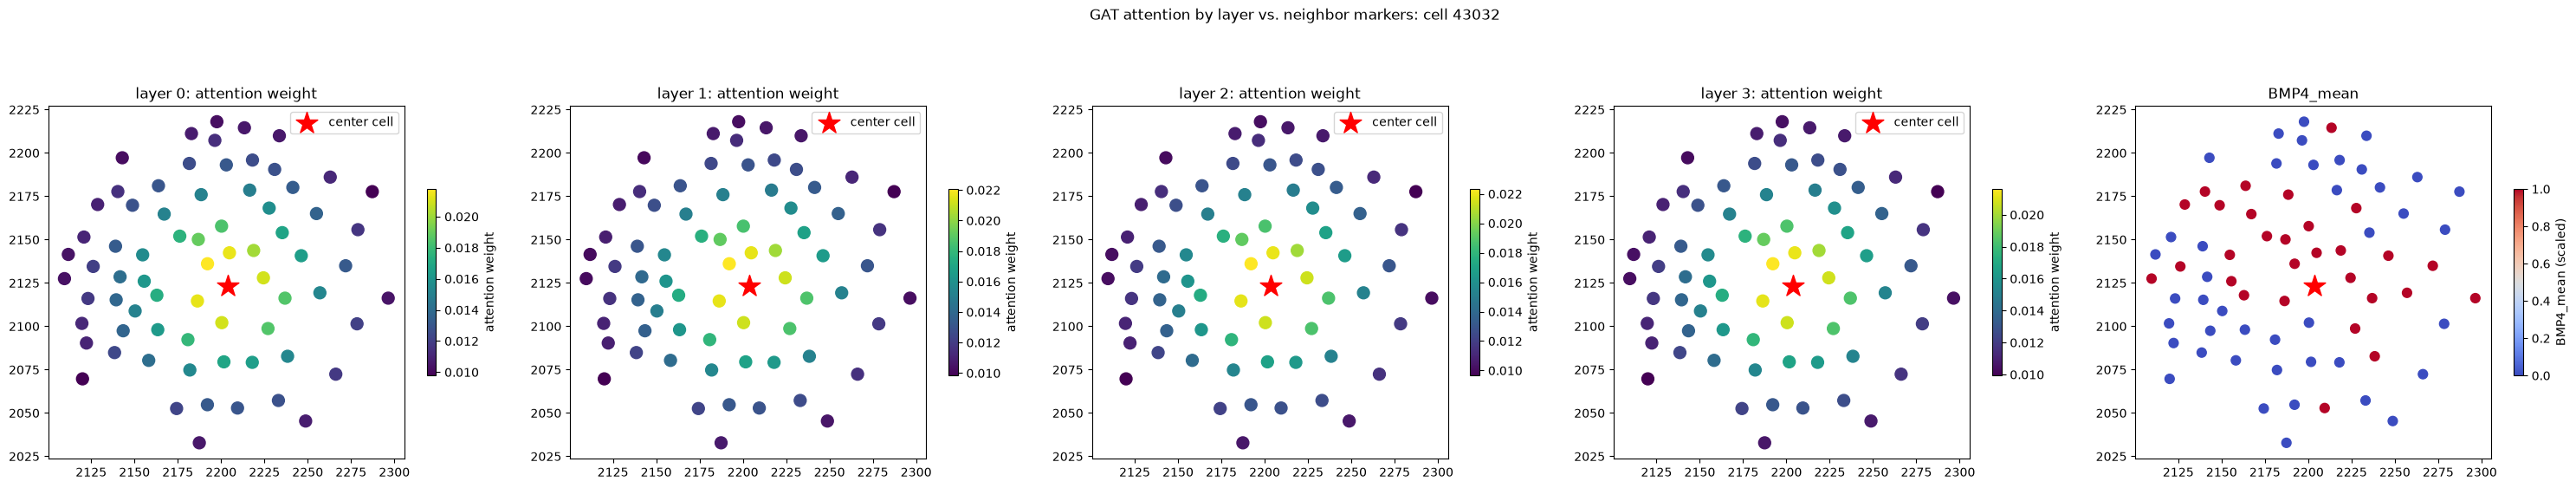

In [ ]:
# One example (held-out test) cell: one attention-weight panel PER LAYER (positions are
# identical across layers -- only the coloring/attention values change, since layer 1's
# attention is a genuinely different, separately-learned quantity from layer 0's, see
# the "distance and neighbor markers, by layer" cell above), then one panel per neighbor
# marker (these don't depend on layer at all, so shown once rather than repeated).

example_cell_pos =np.random.choice(test_idx)
# example_cell_pos = test_idx[i]
mask_edges = (dst == example_cell_pos)
neighbor_pos = src[mask_edges].numpy()

n_layers = len(layer_attentions)
n_panels = n_layers + len(neighbor_cols)
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 6))

for layer_idx, layer_att in enumerate(layer_attentions):
    neighbor_att = layer_att[mask_edges].numpy()
    ax = axes[layer_idx]
    sc = ax.scatter(centroids[neighbor_pos, 1], centroids[neighbor_pos, 0], c=neighbor_att, cmap='viridis', s=100)
    ax.scatter(centroids[example_cell_pos, 1], centroids[example_cell_pos, 0], c='red', s=350, marker='*', label='center cell')
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(sc, ax=ax, label='attention weight', shrink=0.4)
    ax.set_title(f'layer {layer_idx}: attention weight')
    ax.legend()

for j, col in enumerate(neighbor_cols):
    ax = axes[n_layers + j]
    values = pred_data['x_neighbor'][neighbor_pos, j].numpy()
    sc = ax.scatter(centroids[neighbor_pos, 1], centroids[neighbor_pos, 0], c=values, cmap='coolwarm', s=60)
    ax.scatter(centroids[example_cell_pos, 1], centroids[example_cell_pos, 0], c='red', s=350, marker='*')
    ax.set_aspect('equal', adjustable='box')
    fig.colorbar(sc, ax=ax, label=f'{col} (scaled)', shrink=0.4)
    ax.set_title(col)

fig.suptitle(f'GAT attention by layer vs. neighbor markers: cell {cell_df.index[example_cell_pos]}', y=1)
fig.tight_layout()
fig.savefig(f'{fig_dir}/gat_attention_example.png', dpi=300, bbox_inches='tight')
plt.show()